In [2]:
from pathlib import Path
import pandas as pd

# 1. Point directly to your Excel file using Path
excel_file = Path("../..") / "results" / "results.xlsx"

# Load the single Excel file structure
xl = pd.ExcelFile(excel_file)
sheet_names = xl.sheet_names

# Create a dictionary to hold each sheet's DataFrame for easy access
dfs = {}

# 2. Automatically loop through each sheet inside your file
for sheet in sheet_names:
    if "int_" in sheet:
        # For sheets with multi-row headers (run and hit/miss)
        df = pd.read_excel(xl, sheet_name=sheet, header=[0, 1], index_col=0)
        
        # Clean up the multi-level headers so they are perfectly aligned
        cleaned_columns = []
        current_run = ""
        for col in df.columns:
            run_level = col[0]
            status_level = col[1]
            if "Unnamed:" not in str(run_level):
                current_run = run_level
            cleaned_columns.append((current_run, status_level))
            
        df.columns = pd.MultiIndex.from_tuples(cleaned_columns, names=['run', 'status'])
    else:
        # For standard classification sheets (single header row)
        df = pd.read_excel(xl, sheet_name=sheet, index_col=0)
        df.index.name = 'subject'
    
    # Save the dataframe into our dictionary using the sheet name as the key
    dfs[sheet] = df




In [19]:
dfs['int_sift_no_ref']

run        run1      run2      run3      run4      run5     
status      hit miss  hit miss  hit miss  hit miss  hit miss
gras_9_043    4   10    5    9    4   10    3   11    3   11
gras_9_042    2   12    5    9    4   10    4   10    4   10
gras_9_421    0   14    2   12    4   10    6    8    2   12

int_sift_no_ref
sift_no_ref
sift_with_ref
int_with_rot_with_ref
with_rot_no_ref
with_rot_with_ref
int_no_rotation_no_ref
no_rotation_no_ref
no_rot_with_ref


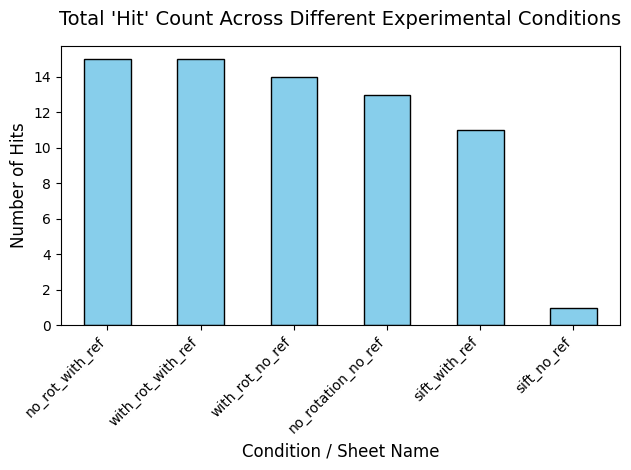

In [17]:
import matplotlib.pyplot as plt

# Dictionary to hold the total hit counts for each classification sheet
total_hits = {}

for sheet_name, df in dfs.items():
    print(sheet_name)
    # Skip interval sheets for this specific plot
    if "int_" in sheet_name:
        continue
        
    # Flatten sheet values, drop NAs, and count how many times 'hit' appears
    counts = df.melt()['value'].dropna().value_counts()
    total_hits[sheet_name] = counts.get('hit', 0)

# Convert to a series and sort the bars from highest to lowest hits
hit_series = pd.Series(total_hits).sort_values(ascending=False)

# Plotting
hit_series.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Total 'Hit' Count Across Different Experimental Conditions", fontsize=14, pad=15)
plt.ylabel("Number of Hits", fontsize=12)
plt.xlabel("Condition / Sheet Name", fontsize=12)
plt.xticks(rotation=45, ha='right')  # Ensures long sheet names don't overlap or truncate
plt.tight_layout()
plt.show()

/tmp/ipykernel_61957/3482911050.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(hit_series.index, rotation=30, ha='right', fontsize=10, color='#2d3748')


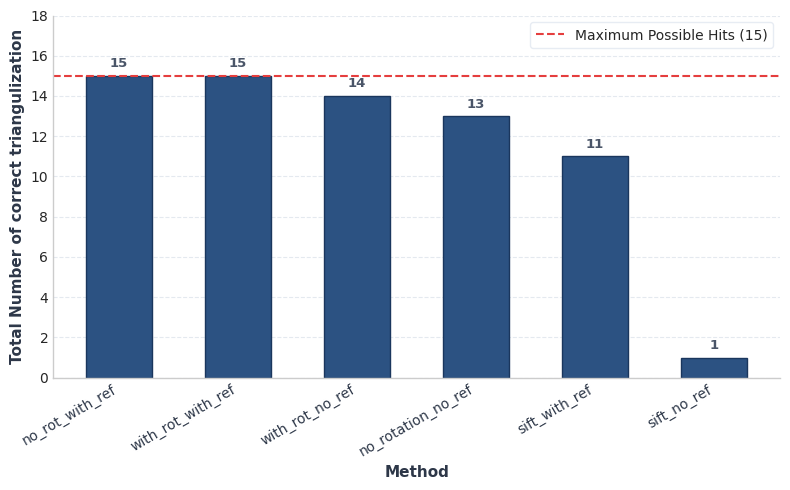

In [25]:
import matplotlib.pyplot as plt
import pandas as pd

# Technical report styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

total_hits = {}

for sheet_name, df in dfs.items():
    clean_label = sheet_name.replace("int_", "")
    
    if isinstance(df.columns, pd.MultiIndex):
        # 1. Interval sheets: Sum all numerical hits across the entire matrix
        hit_data = df.xs('hit', level='status', axis=1)
        total_hits[clean_label] = int(hit_data.sum().sum())
    else:
        # 2. Standard sheets: Count total text occurrences of 'hit'
        counts = df.melt()['value'].dropna().value_counts()
        total_hits[clean_label] = int(counts.get('hit', 0))

# Sort conditions from highest total hits to lowest
hit_series = pd.Series(total_hits).sort_values(ascending=False)

# Plotting setup
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(hit_series.index, hit_series.values, color='#2c5282', edgecolor='#1a365d', width=0.55)

# Add the maximum baseline threshold line at y = 15
ax.axhline(y=15, color='#e53e3e', linestyle='--', linewidth=1.5, label='Maximum Possible Hits (15)')

# Technical report structural cleanup
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='')
ax.grid(axis='y', linestyle='--', alpha=0.5, color='#cbd5e0')

# Typography (No title here - use Overleaf \caption instead)
ax.set_ylabel("Total Number of correct triangulization", fontsize=11, fontweight='semibold', color='#2d3748')
ax.set_xlabel("Method", fontsize=11, fontweight='semibold', color='#2d3748')

# Ensure labels are perfectly legible
ax.set_xticklabels(hit_series.index, rotation=30, ha='right', fontsize=10, color='#2d3748')

# Add a clean legend to explain the red dashed line
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='#e2e8f0')

# Adjust y-axis limit slightly above 15 so the line and text labels have breathing room
ax.set_ylim(0, 18)

# Annotate bars with exact total numbers
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9.5, fontweight='semibold', color='#4a5568')

plt.tight_layout()
plt.show()

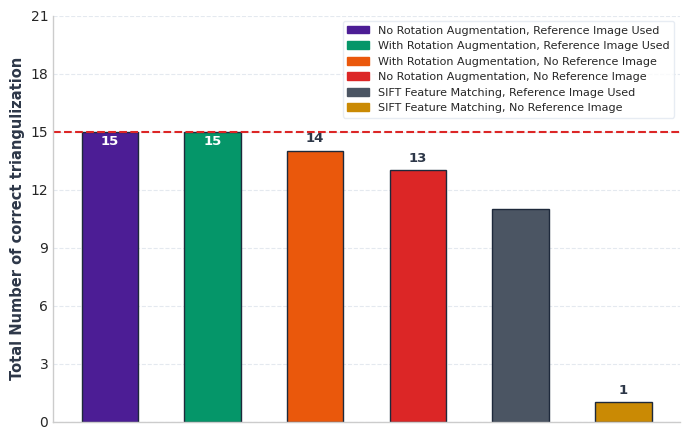

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

# Technical report styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

total_hits = {}

for sheet_name, df in dfs.items():
    clean_label = sheet_name.replace("int_", "")
    
    if isinstance(df.columns, pd.MultiIndex):
        # 1. Interval sheets: Sum all numerical hits across the entire matrix
        hit_data = df.xs('hit', level='status', axis=1)
        total_hits[clean_label] = int(hit_data.sum().sum())
    else:
        # 2. Standard sheets: Count total text occurrences of 'hit'
        counts = df.melt()['value'].dropna().value_counts()
        total_hits[clean_label] = int(counts.get('hit', 0))

# Sort conditions from highest total hits to lowest
hit_series = pd.Series(total_hits).sort_values(ascending=False)

# Replaced with a highly distinct color palette for maximum contrast
color_mapping = {
    "no_rot_with_ref": "#4c1d95",       # Deep Violet
    "with_rot_with_ref": "#059669",     # Emerald Green
    "with_rot_no_ref": "#ea580c",       # Bright Orange
    "no_rotation_no_ref": "#dc2626",    # Crimson Red
    "sift_with_ref": "#4b5563",         # Charcoal Grey
    "sift_no_ref": "#ca8a04"            # Gold
}

# Define the formal descriptions for your legend
formal_names = {
    "no_rot_with_ref": "No Rotation Augmentation, Reference Image Used",
    "with_rot_with_ref": "With Rotation Augmentation, Reference Image Used",
    "with_rot_no_ref": "With Rotation Augmentation, No Reference Image",
    "no_rotation_no_ref": "No Rotation Augmentation, No Reference Image",
    "sift_with_ref": "SIFT Feature Matching, Reference Image Used",
    "sift_no_ref": "SIFT Feature Matching, No Reference Image"
}

# Get the color sequence matched to the sorted index
bar_colors = [color_mapping.get(name, "#cbd5e0") for name in hit_series.index]

# Plotting setup 
fig, ax = plt.subplots(figsize=(7, 4.5))

# Plot bars with the custom high-contrast color list
bars = ax.bar(range(len(hit_series)), hit_series.values, color=bar_colors, edgecolor='#1e293b', width=0.55)

# Add the maximum baseline threshold line precisely at y = 15
ax.axhline(y=15, color='#dc2626', linestyle='--', linewidth=1.5)

# Technical report structural cleanup
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='')
ax.grid(axis='y', linestyle='--', alpha=0.5, color='#cbd5e0')

# Typography (No title or x-axis label here - use Overleaf \caption)
ax.set_ylabel("Total Number of correct triangulization", fontsize=10.5, fontweight='semibold', color='#2d3748')

# Force y-axis to display only whole numbers (integers)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Completely remove x-axis ticks and text labels
ax.set_xticks([])
ax.set_xticklabels([])

# Manually construct the legend handles using your formal descriptions only
legend_handles = [mpatches.Patch(color=color_mapping[name], label=formal_names[name]) for name in hit_series.index]

# Add smaller legend box positioned in the upper right
ax.legend(handles=legend_handles, loc='upper right',
          frameon=True, facecolor='white', edgecolor='#e2e8f0', fontsize=8)

# Set y-axis to scale precisely from 0 to 15
ax.set_ylim(0, 21)

# Annotate bars with exact total numbers
for bar, name in zip(bars, hit_series.index):
    height = bar.get_height()
    
    # If a bar hits the maximum value (15), push text slightly inside the bar
    y_offset = -12 if height == 15 else 4
    
    # Intelligently flip text color to white for better legibility on darker colors
    if height == 15 or name in ["no_rot_with_ref", "with_rot_with_ref", "sift_with_ref"]:
        text_color = 'white'
    else:
        text_color = '#2d3748'
    
    ax.annotate(f'{height}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, y_offset),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9.5, fontweight='bold', color=text_color)

plt.tight_layout()
plt.savefig("\\wsl.localhost\\Ubuntu\\home\\lyngsberg\\bachelor_project\\figures\\res\\3d.pdf")
plt.show()


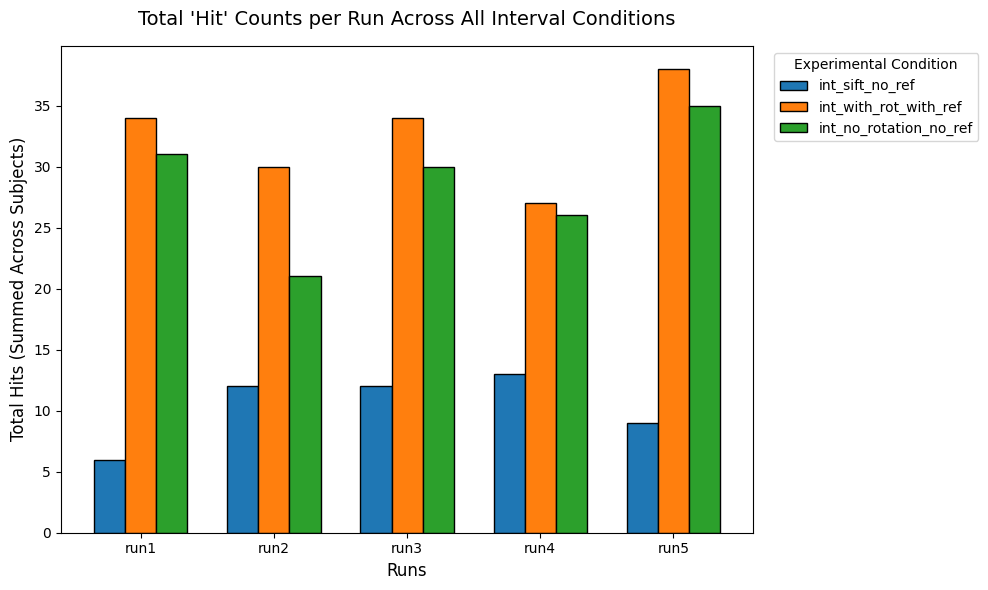

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Dictionary to collect hit counts from all interval sheets
all_interval_hits = {}

for sheet_name, df_target in dfs.items():
    # Only process sheets that start with the "int_" prefix
    if sheet_name.startswith("int_"):
        
        # Sum up values across all subjects (pandas automatically ignores NA values)
        # and unstack the status level ('hit' / 'miss') into columns
        run_summary = df_target.sum(axis=0).unstack(level='status')
        run_summary = run_summary.apply(pd.to_numeric)
        
        # Extract ONLY the 'hit' column and save it under the sheet's name
        if 'hit' in run_summary.columns:
            all_interval_hits[sheet_name] = run_summary['hit']

# 2. Combine the individual sheet hits into a single DataFrame
df_combined_hits = pd.DataFrame(all_interval_hits)

# 3. Filter out any runs (rows) where all conditions are completely empty or 0
df_plot = df_combined_hits[(df_combined_hits > 0).any(axis=1)]

# =========================================================================
# 4. PLOTTING THE COMBINED HITS
# =========================================================================
# Customizing figure size to look great in Jupyter
ax = df_plot.plot(kind='bar', figsize=(10, 6), edgecolor='black', width=0.7)

# Title and labels configuration
plt.title("Total 'Hit' Counts per Run Across All Interval Conditions", fontsize=14, pad=15)
plt.ylabel("Total Hits (Summed Across Subjects)", fontsize=12)
plt.xlabel("Runs", fontsize=12)
plt.xticks(rotation=0)  # Keeps 'run1', 'run2', etc. perfectly horizontal

# Move the legend outside of the plot area so it doesn't overlap your bars
plt.legend(title="Experimental Condition", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

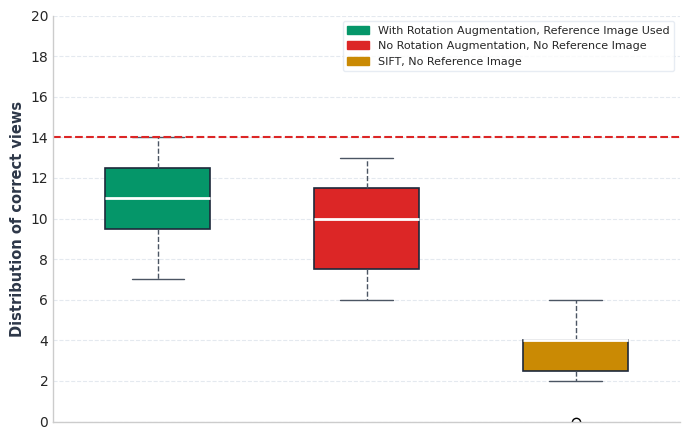

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker  # Import the ticker module

# Technical report styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

all_interval_hits = {}

for sheet_name, df_target in dfs.items():
    if sheet_name.startswith("int_"):
        run_summary = df_target.sum(axis=0).unstack(level='status')
        run_summary = run_summary.apply(pd.to_numeric)
        
        if 'hit' in run_summary.columns:
            clean_name = sheet_name.replace("int_", "")
            # Keep all 15 raw values (3 subjects * 5 runs) un-aggregated as individual rows
            hit_data = df_target.xs('hit', level='status', axis=1).to_numpy().flatten()
            all_interval_hits[clean_name] = hit_data

df_plot = pd.DataFrame(all_interval_hits)

# Order the columns by their median performance (highest to lowest)
sorted_columns = df_plot.median().sort_values(ascending=False).index
df_plot = df_plot[sorted_columns]

# High-contrast color mapping from your previous figure specification
color_mapping = {
    "no_rot_with_ref": "#4c1d95",       # Deep Violet
    "with_rot_with_ref": "#059669",     # Emerald Green
    "with_rot_no_ref": "#ea580c",       # Bright Orange
    "no_rotation_no_ref": "#dc2626",    # Crimson Red
    "sift_with_ref": "#4b5563",         # Charcoal Grey
    "sift_no_ref": "#ca8a04"            # Gold
}

fig, ax = plt.subplots(figsize=(7, 4.5))

# Generate the boxplot
bp = df_plot.boxplot(ax=ax, patch_artist=True, widths=0.5, return_type='dict')

# Style each box with its corresponding custom distinct color
for patch, column_name in zip(bp['boxes'], df_plot.columns):
    box_color = color_mapping.get(column_name, "#cbd5e0")
    patch.set_facecolor(box_color)
    patch.set_edgecolor('#1e293b')
    patch.set_linewidth(1.2)

# Style lines inside the boxplot for an elegant technical finish
for median in bp['medians']:
    median.set_color('white')
    median.set_linewidth(2)
for whisker in bp['whiskers']:
    whisker.set_color('#4b5563')
    whisker.set_linestyle('--')
for cap in bp['caps']:
    cap.set_color('#4b5563')

# Add the maximum baseline line at y = 15
ax.axhline(y=14, color='#dc2626', linestyle='--', linewidth=1.5)

# Technical report axis modifications
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', linestyle='')
ax.grid(axis='y', linestyle='--', alpha=0.5, color='#cbd5e0')

# Labels and parameters matching your clean, textless style
ax.set_ylabel("Distribution of correct views", fontsize=10.5, fontweight='semibold', color='#2d3748')
ax.set_ylim(0, 20)  # Cap right above the 15 max to frame it nicely

# Force y-axis to display only whole numbers (integers)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Completely strip out the X-axis text labels and title for Overleaf integration
ax.set_xticks([])
ax.set_xticklabels([])
ax.set_xlabel("")


formal_names = {
    "no_rot_with_ref": "No Rotation Augmentation, Reference Image Used",
    "with_rot_with_ref": "With Rotation Augmentation, Reference Image Used",
    "with_rot_no_ref": "With Rotation Augmentation, No Reference Image",
    "no_rotation_no_ref": "No Rotation Augmentation, No Reference Image",
    "sift_with_ref": "SIFT, Reference Image Used",
    "sift_no_ref": "SIFT, No Reference Image"
}


# Construct custom legend matching your colors to descriptions
legend_handles = [mpatches.Patch(color=color_mapping[col], label=formal_names.get(col, col)) for col in df_plot.columns]
ax.legend(handles=legend_handles, loc='upper right', frameon=True, facecolor='white', edgecolor='#e2e8f0', fontsize=8)

plt.tight_layout()
plt.savefig("int_pdf", bbox_inches="tight", dpi=300)
plt.show()